In [2]:
import pandas as pd
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from sklearn.utils.class_weight import compute_class_weight

In [3]:
import os
for dirname, _,filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/himanshuraturi2302
/kaggle/input/datasets/himanshuraturi2302/dataset
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Water_Disaster
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Non_Damage
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Damaged_Infrastructure
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Human_Damage
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Fire_Disaster
/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Land_Disa

In [4]:
DATASET_PATH = "/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented"

In [5]:
print(os.listdir(DATASET_PATH))

['Water_Disaster', 'Non_Damage', 'Damaged_Infrastructure', 'Human_Damage', 'Fire_Disaster', 'Land_Disaster']


### Class Distribution

In [6]:
def get_class_distribution(dataset_path):
    class_counts = {}
    
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    
    return class_counts

class_counts = get_class_distribution(DATASET_PATH)
print(class_counts)

{'Water_Disaster': 1398, 'Non_Damage': 12470, 'Damaged_Infrastructure': 1963, 'Human_Damage': 325, 'Fire_Disaster': 1260, 'Land_Disaster': 887}


In [7]:
df = pd.DataFrame(list(class_counts.items()) , columns=["Class" , "Count"])
df["Percentage"] = (df["Count"] / df["Count"].sum()) * 100

print(df.sort_values(by="Count" , ascending=False))

                    Class  Count  Percentage
1              Non_Damage  12470   68.130908
2  Damaged_Infrastructure   1963   10.725018
0          Water_Disaster   1398    7.638092
4           Fire_Disaster   1260    6.884117
5           Land_Disaster    887    4.846200
3            Human_Damage    325    1.775665


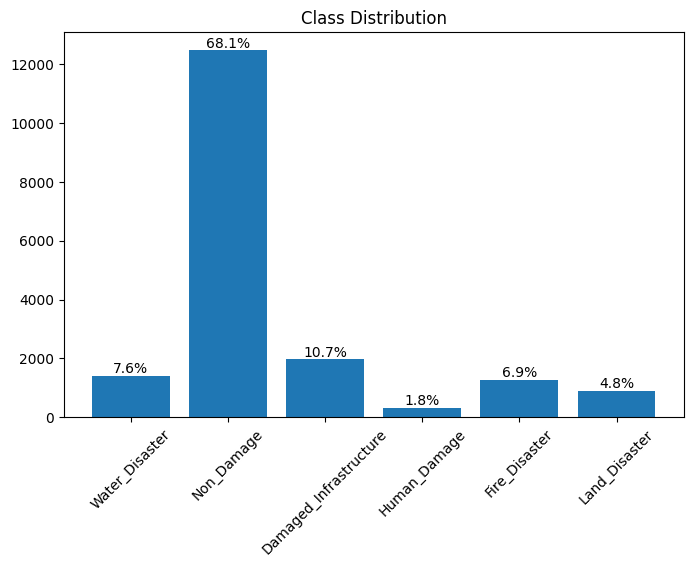

In [8]:
plt.figure(figsize=(8,5))
bars = plt.bar(df["Class"], df["Count"])

for bar, pct in zip(bars, df["Percentage"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{pct:.1f}%", ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

### Sample Images Visualization

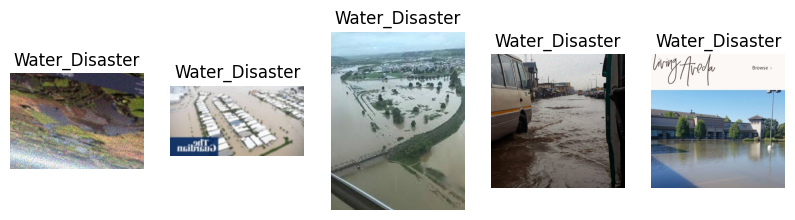

In [9]:
def show_samples(class_name, n=5):
    path = os.path.join(DATASET_PATH, class_name)
    images = random.sample(os.listdir(path), n)
    
    plt.figure(figsize=(10,5))
    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(path, img_name))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)
    plt.show()

# Example
show_samples("Water_Disaster")

### Image Size Analysis

In [10]:
widths, heights = [], []

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path)[:200]:
        img = Image.open(os.path.join(cls_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

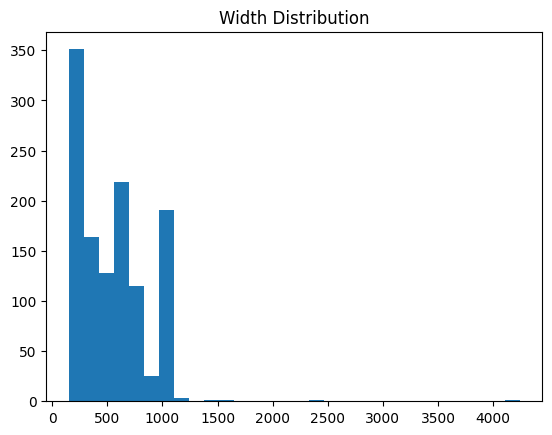

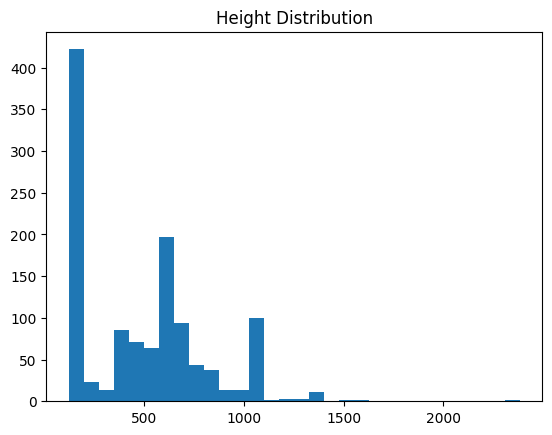

In [11]:
plt.hist(widths, bins=30)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=30)
plt.title("Height Distribution")
plt.show()

### Pixel Intensity (Lighting Analysis)

In [12]:
pixel_means = []

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path)[:200]:
        img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
        arr = np.array(img) / 255.0
        pixel_means.append(arr.mean())

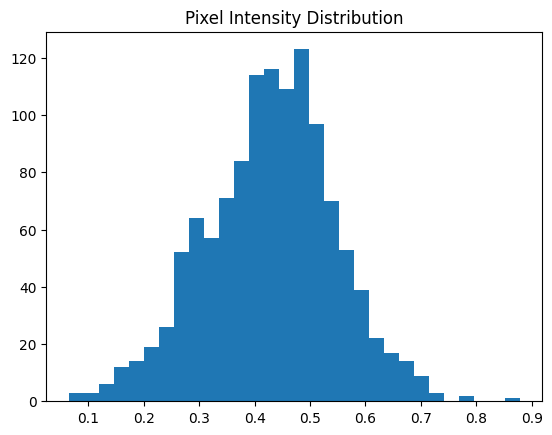

In [13]:
plt.hist(pixel_means, bins=30)
plt.title("Pixel Intensity Distribution")
plt.show()

### Blur Detection (Quality Check)

In [14]:
def detect_blur(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [15]:
blur_scores = []

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path)[:100]:
        path = os.path.join(cls_path, img_name)
        score = detect_blur(path)
        blur_scores.append(score)

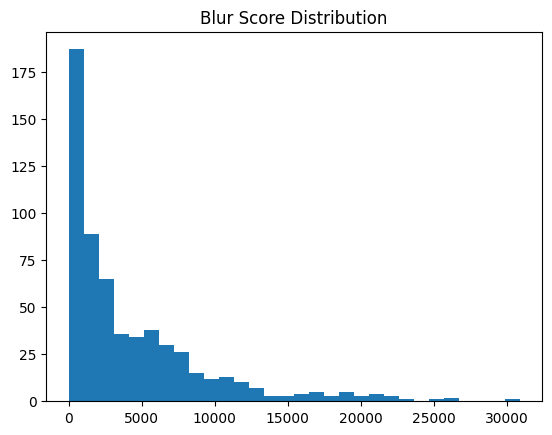

In [16]:
plt.hist(blur_scores, bins=30)
plt.title("Blur Score Distribution")
plt.show()

### Class Weights (for imbalance)

In [17]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

y = []
for cls, count in zip(classes, counts):
    y.extend([cls] * count)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(classes),
    y=np.array(y)
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{'Water_Disaster': np.float64(2.182045779685265), 'Non_Damage': np.float64(0.2446271050521251), 'Damaged_Infrastructure': np.float64(1.553998981151299), 'Human_Damage': np.float64(9.386153846153846), 'Fire_Disaster': np.float64(2.421031746031746), 'Land_Disaster': np.float64(3.4391206313416007)}


### Basic Preprocessing Transforms (PyTorch)

In [18]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3)],
        p=0.3
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Custom Dataset Class

In [19]:
from torch.utils.data import Dataset

class DisasterDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []
        
        for idx, cls in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls)
            
            for img_name in os.listdir(cls_path):
                self.image_paths.append(os.path.join(cls_path, img_name))
                self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

### Train / Validation Split

In [20]:
from torch.utils.data import random_split

dataset = DisasterDataset(DATASET_PATH, transform=train_transforms)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

### DataLoader

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 458
Val batches: 115


### Training Loop

In [22]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Modify final layer
num_classes = 6
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 230MB/s]


In [23]:
class_weights_tensor = torch.tensor(
    list(class_weights.values()),
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [24]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [25]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

In [26]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

In [29]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion
    )

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

100%|██████████| 458/458 [04:55<00:00,  1.55it/s]


Epoch 1
Train Loss: 0.4636, Train Acc: 0.8273
Val Loss: 0.3510, Val Acc: 0.8730


100%|██████████| 458/458 [04:16<00:00,  1.79it/s]


Epoch 2
Train Loss: 0.3537, Train Acc: 0.8671
Val Loss: 0.3284, Val Acc: 0.8782


100%|██████████| 458/458 [04:14<00:00,  1.80it/s]


...

Epoch 8
Train Loss: 0.2582, Train Acc: 0.8987
Val Loss: 0.2690, Val Acc: 0.9060


100%|██████████| 458/458 [04:14<00:00,  1.80it/s]


Epoch 9
Train Loss: 0.2442, Train Acc: 0.9062
Val Loss: 0.2984, Val Acc: 0.8978


100%|██████████| 458/458 [04:14<00:00,  1.80it/s]


Epoch 10
Train Loss: 0.2294, Train Acc: 0.9103
Val Loss: 0.3108, Val Acc: 0.9041


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

In [31]:
y_true, y_pred = evaluate_model(model, val_loader)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       401
           1       0.99      0.59      0.74       251
           2       0.86      0.61      0.71        61
           3       0.57      0.75      0.65       197
           4       0.97      0.98      0.98      2465
           5       0.79      0.78      0.78       286

    accuracy                           0.91      3661
   macro avg       0.83      0.76      0.78      3661
weighted avg       0.91      0.91      0.90      3661



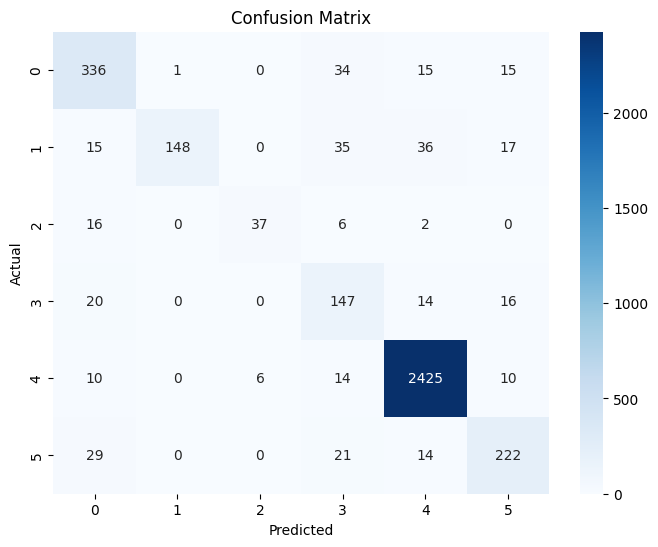

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
accuracy = (y_true == y_pred).mean()
print("Accuracy:", accuracy)

Accuracy: 0.9054903031958481


In [34]:
torch.save(model.state_dict(), "resnet50_disaster.pth")